# Red Hospitalaria — Análisis de Red y Trayectorias

Análisis del grafo de traslados entre hospitales de la Red Sudeste.
Incluye: mapa de la red, métricas (betweenness, SSR), flujos frecuentes y evolución temporal.


In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))
from src.config import *
from src.io import *
from src.procesamiento import *
from src.visualizacion import *
from src.funciones_complejas import *

import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("..")  # para importar desde /scripts

# from scripts import bases, init_notebook as init


In [3]:
# Cargar todos los datos del proyecto en una sola línea
ctx = init_notebook(data_path="../data")

df_pacientes   = ctx["df_pacientes"]
traslados      = ctx["traslados"]
hosp_coords    = ctx["hosp_coords"]
municipios     = ctx["municipios"]
municipios_amba = ctx["municipios_amba"]


Cargando datos de pacientes...
[reconstruir_traslados] Se descartaron 82 traslados con error grave de fechas.
  → 29,696 registros | 27,294 pacientes únicos
  → 1,681 traslados reconstruidos
Cargando datos geográficos...
  → 14 hospitales con coordenadas
  → 9 municipios AMBA cargados

✓ Entorno listo.

--- CHEQUEO POST-LIMPIEZA ---
Filas:              29696
Pacientes únicos:   27294
Hospitales únicos:  15
Valores nulos (Fecha inicio): 3168
Valores nulos (Fecha egreso): 4023

Distribución tipo_egreso:
tipo_egreso
alta           17519
traslado        5330
otro            3580
muerte          2791
desconocido      476
Name: count, dtype: int64

Distribución evolución:
evolucion
 0    27147
-1     1392
 1      944
-2      200
 2       13
Name: count, dtype: int64


In [ ]:
df_pacientes['tipo_egreso'].unique()

<StringArray>
['desconocido', 'alta', 'otro', 'traslado', 'muerte']
Length: 5, dtype: str

## 1. Funcionamiento de la Red General (AMBA)

### 1.1 Mapa con los hospitales y sus municipios alrededor

In [7]:
# Generar red
G, edges, fig_tuple = analizar_red_hospitalaria(
    traslados, hosp_coords, 
    peso_minimo=1, 
    modo="estatico", 
    mostrar_resumen=True, 
    graficar=False
)

# Convertir red y nodos a GeoDataFrames con curvas
gdf_edges, gdf_nodes = gdf_red_hospitalaria(G, hosp_coords)

# Graficar sobre AMBA
# plot_red_sobre_amba(gdf_edges, gdf_nodes, municipios_amba, mostrar_nombres=True, mostrar_peso=False)

Registros luego de filtros: 1681
Hospitales origen únicos: 13
Hospitales destino únicos: 13
Nodos en red: 14
Aristas en red: 49


### 1.2 Total de traslados

In [8]:
# Resumen de traslados
res_tras = resumen_traslados(traslados, imprimir=True)

Total de traslados: 1681
Cantidad de hospitales únicos: 13


### 1.3 Cantidad de traslados en función del tiempo

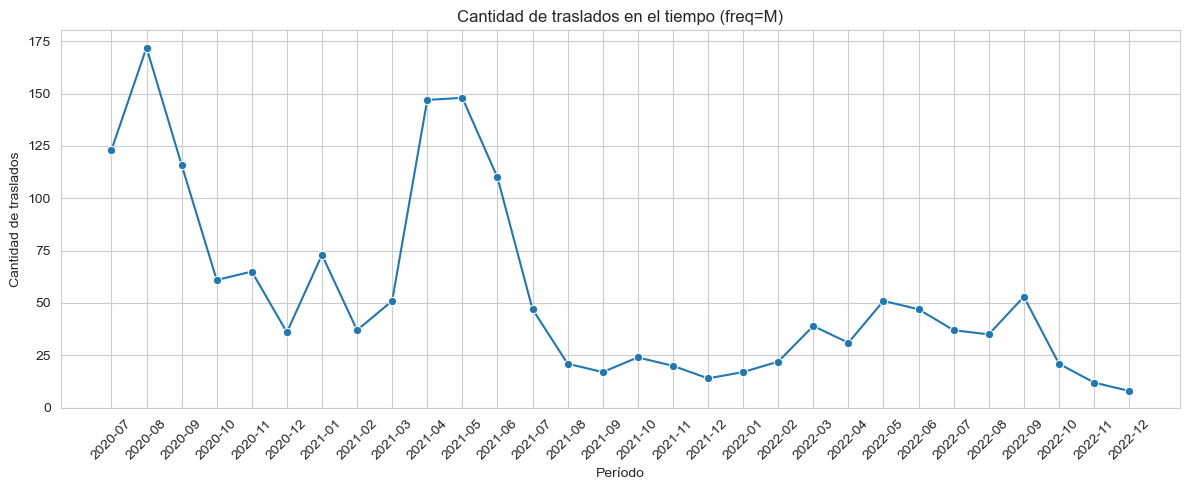

Fecha egreso
2020-07    123
2020-08    172
2020-09    116
2020-10     61
2020-11     65
2020-12     36
2021-01     73
2021-02     37
2021-03     51
2021-04    147
2021-05    148
2021-06    110
2021-07     47
2021-08     21
2021-09     17
2021-10     24
2021-11     20
2021-12     14
2022-01     17
2022-02     22
2022-03     39
2022-04     31
2022-05     51
2022-06     47
2022-07     37
2022-08     35
2022-09     53
2022-10     21
2022-11     12
2022-12      8
dtype: int64

In [9]:
traslados_en_el_tiempo(traslados, freq="M")

### 1.4 Top de flujos entre hospitales (Caminos más frecuentes)

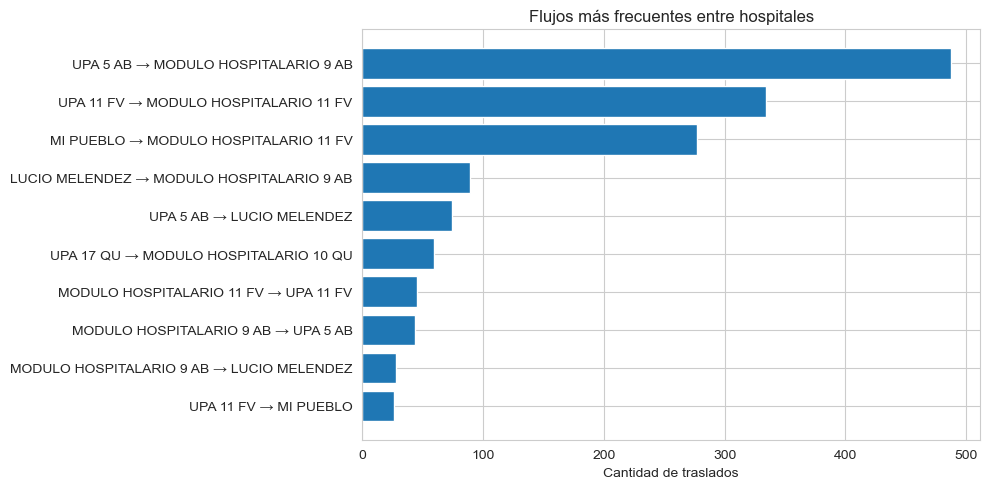

,Nombre Hospital,Hospital siguiente,cantidad
47,UPA 5 AB,MODULO HOSPITALARIO 9 AB,487
41,UPA 11 FV,MODULO HOSPITALARIO 11 FV,334
17,MI PUEBLO,MODULO HOSPITALARIO 11 FV,277
14,LUCIO MELENDEZ,MODULO HOSPITALARIO 9 AB,89
46,UPA 5 AB,LUCIO MELENDEZ,74
43,UPA 17 QU,MODULO HOSPITALARIO 10 QU,59
26,MODULO HOSPITALARIO 11 FV,UPA 11 FV,45
30,MODULO HOSPITALARIO 9 AB,UPA 5 AB,44
28,MODULO HOSPITALARIO 9 AB,LUCIO MELENDEZ,28
40,UPA 11 FV,MI PUEBLO,26


In [10]:
top_flujos_hospitales(traslados, top_n=10)

### 1.5 Métricas de la red (Grafos)

In [11]:
metricas_red(G, top_n=10)

Top hospitales por betweenness:
                     hospital  degree_centrality  betweenness  in_degree  \
0                    EL CRUCE           1.461538     0.560897        103   
11                      OLLER           0.384615     0.253205          4   
4   MODULO HOSPITALARIO 10 QU           0.846154     0.195513         72   
10                  UPA 17 QU           0.384615     0.076923          6   
12                   ONATIVIA           0.538462     0.073718          5   
6    MODULO HOSPITALARIO 9 AB           0.692308     0.067308        591   
1                     IRIARTE           0.461538     0.016026         18   
3                   MI PUEBLO           0.538462     0.012821         39   
5   MODULO HOSPITALARIO 11 FV           0.461538     0.000000        617   
2              LUCIO MELENDEZ           0.461538     0.000000        103   

    out_degree  
0           15  
11           3  
4           39  
10          62  
12          29  
6           77  
1           

,hospital,degree_centrality,betweenness,in_degree,out_degree
0,EL CRUCE,1.461538,0.560897,103,15
11,OLLER,0.384615,0.253205,4,3
4,MODULO HOSPITALARIO 10 QU,0.846154,0.195513,72,39
10,UPA 17 QU,0.384615,0.076923,6,62
12,ONATIVIA,0.538462,0.073718,5,29
6,MODULO HOSPITALARIO 9 AB,0.692308,0.067308,591,77
1,IRIARTE,0.461538,0.016026,18,18
3,MI PUEBLO,0.538462,0.012821,39,302
5,MODULO HOSPITALARIO 11 FV,0.461538,0.000000,617,76
2,LUCIO MELENDEZ,0.461538,0.000000,103,113
